In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Importing 100K instances from the dataset
df = pd.read_csv("/Users/nathal/ieee-fraud-detection/train_transaction.csv", nrows=100000)

In [3]:
df.shape
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
#Types of variables in the dataset
df.dtypes.value_counts()

float64    376
object      14
int64        4
Name: count, dtype: int64

In [5]:
#Looking for target variable
df.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=394)

In [6]:
#Checking for distribution of target variable 
df['isFraud'].value_counts()
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.97439
1    0.02561
Name: proportion, dtype: float64

In [8]:
#Identifying missing values
missing = df.isnull().mean().sort_values(ascending=False)
high_missing = missing[missing > 0.8]
high_missing

D7       0.93928
dist2    0.91769
D13      0.90479
D12      0.89495
D14      0.88847
D6       0.87259
M7       0.83961
M8       0.83961
M9       0.83961
dtype: float64

In [10]:
#Removing ones with more than 80% missing values
df = df.drop(columns=high_missing.index)
df.shape

(100000, 385)

In [11]:
#Checking for zero variance features
nunique = df.nunique()

zero_var = nunique[nunique <= 1].index
zero_var

Index(['M1', 'V107'], dtype='object')

In [12]:
#Removing zero variance features
df = df.drop(columns=zero_var)
df.shape

(100000, 383)

In [14]:
#Checking for skewed features
skew = df.skew(numeric_only=True).sort_values(ascending=False)
skewed_features = skew[abs(skew) > 2]
skewed_features

V305    223.591145
V319    183.545069
V321    176.399410
V320    159.321857
V214    125.565419
           ...    
V41     -28.948517
V88     -29.803200
V14     -37.894048
V65     -46.659676
V1      -75.868306
Length: 304, dtype: float64

array([[<Axes: title={'center': 'V305'}>,
        <Axes: title={'center': 'V319'}>,
        <Axes: title={'center': 'V321'}>],
       [<Axes: title={'center': 'V320'}>,
        <Axes: title={'center': 'V214'}>,
        <Axes: title={'center': 'V276'}>],
       [<Axes: title={'center': 'V135'}>,
        <Axes: title={'center': 'V137'}>,
        <Axes: title={'center': 'V226'}>],
       [<Axes: title={'center': 'V278'}>, <Axes: >, <Axes: >]],
      dtype=object)

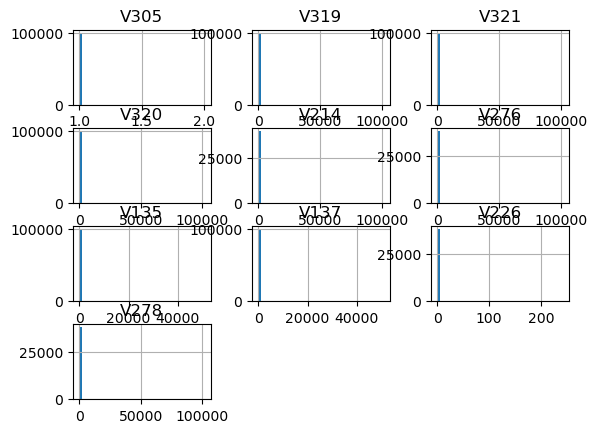

In [18]:
#Inspect top ones
skew_sorted = skew.abs().sort_values(ascending=False)
top_skewed = skew_sorted.head(10).index
top_skewed
df[top_skewed].hist(bins=50)

In [29]:
#Understanding the distribution of the top skewed features, one at a time
df['V1'].describe()

count    28792.000000
mean         0.999826
std          0.013177
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: V1, dtype: float64

In [30]:
#Transforming skewed features with wide continuous range
import numpy as np

for col in ['V319', 'V321', 'V320', 'V214']:
    df[col + '_log'] = np.log1p(df[col])

In [33]:
#Checking correlation with target variable
corr = df.corr(numeric_only=True)['isFraud'].sort_values(ascending=False)
corr.head(10)

isFraud    1.000000
V201       0.340504
V189       0.317358
V200       0.298870
V257       0.289347
V45        0.275433
V188       0.270014
V156       0.250835
V246       0.249517
V149       0.238343
Name: isFraud, dtype: float64

In [34]:
corr.tail(10)

D2    -0.081742
V30   -0.096279
V70   -0.097820
V29   -0.098518
V91   -0.099436
V69   -0.099975
V49   -0.101217
V90   -0.102442
V48   -0.103115
D8    -0.112265
Name: isFraud, dtype: float64

In [39]:
#Encoding categorical data before models are applied, using one-hot encoding
cat_cols = df.select_dtypes(include='object').columns
cat_cols

df = pd.get_dummies(df, columns=cat_cols, drop_first=True) #one-hot encoding

In [40]:
#Validating encoding was done
df.dtypes.value_counts()

float64    373
bool       133
int64        4
Name: count, dtype: int64

In [41]:
#Splitting data and establishing a baseline using a dummy classifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split data
X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Baseline model
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

# Predictions
y_pred = dummy.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     19488
           1       0.00      0.00      0.00       512

    accuracy                           0.97     20000
   macro avg       0.49      0.50      0.49     20000
weighted avg       0.95      0.97      0.96     20000



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [54]:
#Running PR-AUC for the baseline model
from sklearn.metrics import average_precision_score

# Get probabilities for class 1 (fraud)
y_probs_dummy = dummy.predict_proba(X_test)[:, 1]

# Compute PR-AUC
pr_auc_dummy = average_precision_score(y_test, y_probs_dummy)

print("Baseline PR-AUC:", pr_auc_dummy)

Baseline PR-AUC: 0.0256


In [42]:
#Validating hypothesis with chosen model - RF
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

#Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19488
           1       0.97      0.42      0.59       512

    accuracy                           0.98     20000
   macro avg       0.98      0.71      0.79     20000
weighted avg       0.98      0.98      0.98     20000



In [68]:
#Running the confusion matrix for RF
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[19481     7]
 [  295   217]]


In [70]:
#Running MCC for RF
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test, y_pred)
print(mcc)

0.6355459144507757


In [44]:
#Running PR-AUC for RF
from sklearn.metrics import average_precision_score

#Get probabilities for class 1 (fraud)
y_probs = rf.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_probs)
print("PR-AUC:", pr_auc)

PR-AUC: 0.6666676123832258


In [45]:
#Comparing to GB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

#Model
gb = GradientBoostingClassifier(random_state=42)

#Train
gb.fit(X_train, y_train)

#Predict
y_pred_gb = gb.predict(X_test)

#Evaluate
print(classification_report(y_test, y_pred_gb))

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [46]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [51]:
#2nd attempt to run GB after median imputation
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

#Model
gb = GradientBoostingClassifier(random_state=42)

#Train
gb.fit(X_train_imputed, y_train)

#Predict
y_pred_gb = gb.predict(X_test_imputed)

#Evaluate
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19488
           1       0.91      0.32      0.47       512

    accuracy                           0.98     20000
   macro avg       0.94      0.66      0.73     20000
weighted avg       0.98      0.98      0.98     20000



In [71]:
#Running Confusion matrix for GB

cm = confusion_matrix(y_test, y_pred_gb)
print(cm)

[[19471    17]
 [  348   164]]


In [72]:
#Running MCC for GB
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test, y_pred_gb)
print(mcc)

0.5327555537038723


In [53]:
#Running PR-AUC for GB
from sklearn.metrics import average_precision_score

#Get probabilities for class 1 (fraud)
y_probs_gb = gb.predict_proba(X_test_imputed)[:, 1]

#Compute PR-AUC
pr_auc_gb = average_precision_score(y_test, y_probs_gb)

print("GB PR-AUC:", pr_auc_gb)

GB PR-AUC: 0.561753000203646


In [67]:
#Checking if the imputation impacted the performance of the model by running the imputated dataset on RF
rf_imputed = RandomForestClassifier(random_state=42)

rf_imputed.fit(X_train_imputed, y_train)

y_pred_rf_imputed = rf_imputed.predict(X_test_imputed)
y_probs_rf_imputed = rf_imputed.predict_proba(X_test_imputed)[:, 1]

from sklearn.metrics import average_precision_score

pr_auc_rf_imputed = average_precision_score(y_test, y_probs_rf_imputed)

print("RF (imputed) PR-AUC:", pr_auc_rf_imputed)

RF (imputed) PR-AUC: 0.6712462159154283


In [55]:
#Tuning the RF model, attempting to achieve improved results
rf_tuned = RandomForestClassifier(
    n_estimators=50,      # limiting number of trees
    max_features=10,      # limiting number of features per split
    max_depth=10,         # limiting depth of each tree
    class_weight='balanced', #handling the imbalance in the data
    random_state=42
)

#Training the model
rf_tuned.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
#Running prediction of the tuned RF model on the test sample
# Predict
y_pred_rf_tuned = rf_tuned.predict(X_test)

In [58]:
#Evaluating the tuned RF performance
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95     19488
           1       0.17      0.69      0.27       512

    accuracy                           0.90     20000
   macro avg       0.58      0.80      0.61     20000
weighted avg       0.97      0.90      0.93     20000



In [60]:
#Running Confusion matrix for tuned RF
cm = confusion_matrix(y_test, y_pred_rf_tuned)
print(cm)

[[17744  1744]
 [  159   353]]


In [73]:
#Running MCC for tuned RF
mcc = matthews_corrcoef(y_test, y_pred_rf_tuned)
print(mcc)

0.3093003077789281


In [61]:
#Calculating PR-AUC for tuned RF
y_probs = rf_tuned.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_probs)
print("PR-AUC:", pr_auc)

PR-AUC: 0.5008637078673922


In [63]:
#Trying to play with tuning, focusing on thresholds
from sklearn.metrics import f1_score

thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_t = (y_probs > t).astype(int)
    print(f"\nThreshold: {t}")
    print("F1:", f1_score(y_test, y_pred_t))


Threshold: 0.1
F1: 0.050359712230215826

Threshold: 0.15
F1: 0.05753923129406414

Threshold: 0.2
F1: 0.07576456124173966

Threshold: 0.25
F1: 0.09324695720455438

Threshold: 0.3
F1: 0.1055025011368804

Threshold: 0.4
F1: 0.18125

Threshold: 0.5
F1: 0.2706017631276351


In [65]:
#Trying a different approach to training - cross-validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring='average_precision')

print(scores)
print("Mean PR-AUC:", scores.mean())

[0.02054544 0.35983411 0.39708735 0.59827521 0.58263209]
Mean PR-AUC: 0.3916748366320394


In [66]:
#Using stratified cross-validation, to maintain the same class ratio across all splits
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring='average_precision'
)

print(scores)
print("Mean PR-AUC:", scores.mean())

[0.66980301 0.66229594 0.64594337 0.65124122 0.66214167]
Mean PR-AUC: 0.6582850413894785
